## **Objective** : Predict if a passenger can survive on the titanic or not.

## Import Libraries :

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv


## Read Data :

In [2]:
train = pd.read_csv('/kaggle/input/titanic/train.csv')
test = pd.read_csv('/kaggle/input/titanic/test.csv')

In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 1. Exploratory Data Analysis
- Identify the target :
Survived
- Number of lines and columns :
(891, 12)
- Type of variables :
Quantitative variables : 7
Qualitative : 5
- Identification of missing values :
    - a lot of Nan variables in Cabin column = 70 % -->  missing values can be a significant information in that case
    - many Nan variables in Age column = 20 % 


In [4]:
n = len(train)
train.shape

(891, 12)

In [5]:
train.dtypes.value_counts()

object     5
int64      5
float64    2
dtype: int64

In [6]:
train.isna().sum() / train.shape[0] * 100

PassengerId     0.000000
Survived        0.000000
Pclass          0.000000
Name            0.000000
Sex             0.000000
Age            19.865320
SibSp           0.000000
Parch           0.000000
Ticket          0.000000
Fare            0.000000
Cabin          77.104377
Embarked        0.224467
dtype: float64

<AxesSubplot:>

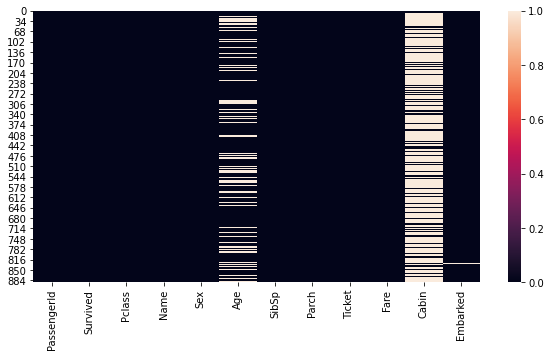

In [7]:
plt.figure(figsize=(10, 5))
sns.heatmap(train.isna())

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [9]:
train.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"McDermott, Miss. Brigdet Delia",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


 ## Target visualization :

<AxesSubplot:title={'center':'Target distribution'}>

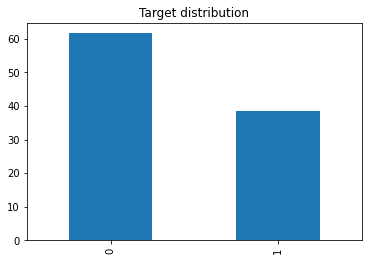

In [10]:
(train.Survived.value_counts() / train.shape[0] * 100).plot.bar(title='Target distribution')

 ## Quantitative variables :

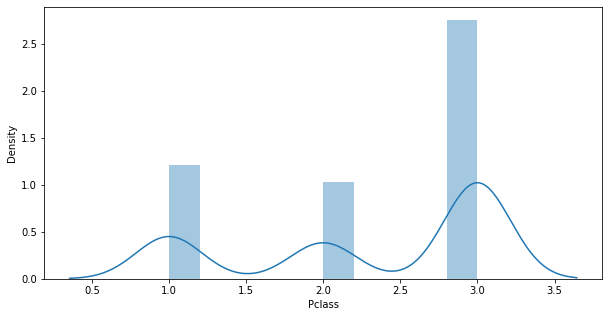

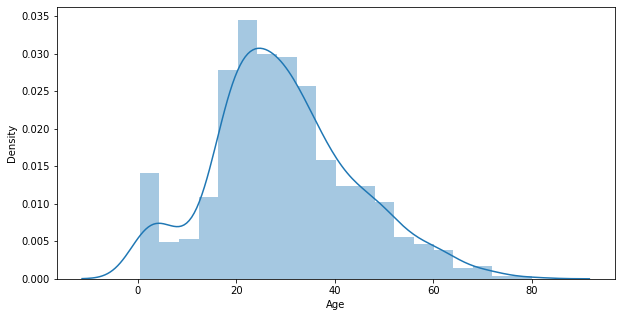

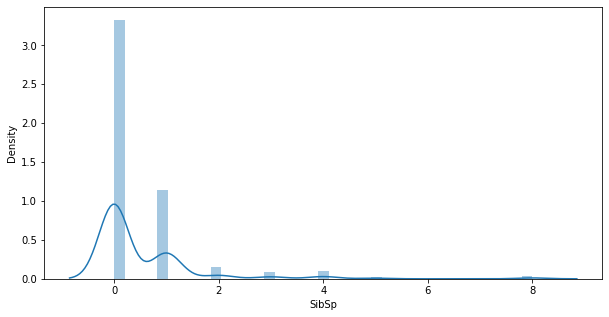

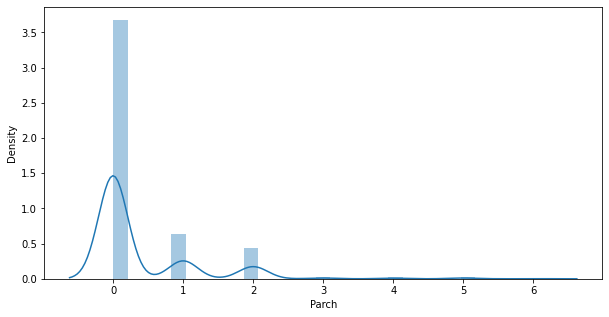

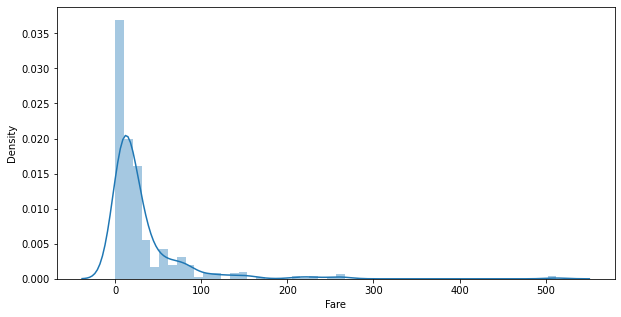

In [11]:
quantitative_col = [ 'Pclass', 'Age', 'SibSp',
       'Parch', 'Fare']

for col in quantitative_col :
    plt.figure(figsize=(10, 5))
    sns.distplot(train[col])

- The target is not perfectly distributed on Survived and unSurvived peaple, so using F-score as a metric is a good option
- Pclass, SibSp and Parch can be encoded as they contain just some diffirent values 
- Age and Fare may be normalized

 ## Qualitative variables :

In [12]:
train.select_dtypes('object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [13]:
qualitative_col = ['Sex', 'Ticket', 'Cabin', 'Embarked']

for col in qualitative_col :
    print(f'{col :-<50} {train[col].unique()}')

Sex----------------------------------------------- ['male' 'female']
Ticket-------------------------------------------- ['A/5 21171' 'PC 17599' 'STON/O2. 3101282' '113803' '373450' '330877'
 '17463' '349909' '347742' '237736' 'PP 9549' '113783' 'A/5. 2151'
 '347082' '350406' '248706' '382652' '244373' '345763' '2649' '239865'
 '248698' '330923' '113788' '347077' '2631' '19950' '330959' '349216'
 'PC 17601' 'PC 17569' '335677' 'C.A. 24579' 'PC 17604' '113789' '2677'
 'A./5. 2152' '345764' '2651' '7546' '11668' '349253' 'SC/Paris 2123'
 '330958' 'S.C./A.4. 23567' '370371' '14311' '2662' '349237' '3101295'
 'A/4. 39886' 'PC 17572' '2926' '113509' '19947' 'C.A. 31026' '2697'
 'C.A. 34651' 'CA 2144' '2669' '113572' '36973' '347088' 'PC 17605' '2661'
 'C.A. 29395' 'S.P. 3464' '3101281' '315151' 'C.A. 33111' 'S.O.C. 14879'
 '2680' '1601' '348123' '349208' '374746' '248738' '364516' '345767'
 '345779' '330932' '113059' 'SO/C 14885' '3101278' 'W./C. 6608'
 'SOTON/OQ 392086' '343275' '343276' '3

- Embarked and Sex columns can easily be encoded
- for Ticket, cabin and name columns we can extract other meaningful ones = Feature engineering 

 ## Relationship between target and variables :

In [14]:
train.drop('PassengerId', axis = 1, inplace = True)

In [15]:
# color palette from seaborn
cm = sns.light_palette("green", as_cmap=True)
 
# Visualizing the DataFrame with set precision
train.corr().style.background_gradient(cmap=cm).set_precision(2)

,Survived,Pclass,Age,SibSp,Parch,Fare
Survived,1.00,-0.34,-0.08,-0.04,0.08,0.26
Pclass,-0.34,1.00,-0.37,0.08,0.02,-0.55
Age,-0.08,-0.37,1.00,-0.31,-0.19,0.10
SibSp,-0.04,0.08,-0.31,1.00,0.41,0.16
Parch,0.08,0.02,-0.19,0.41,1.00,0.22
Fare,0.26,-0.55,0.10,0.16,0.22,1.00


In [16]:
survived_people = train[train.Survived == 1]
unsurvived_people = train[train.Survived == 0]

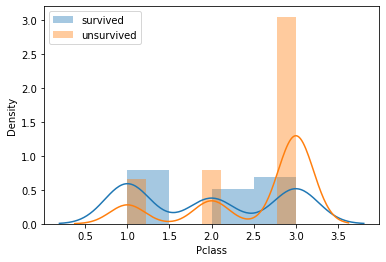

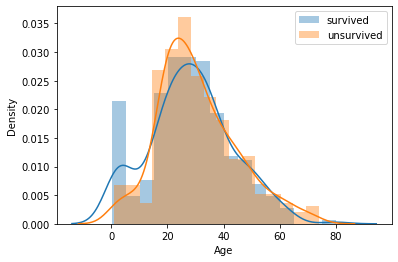

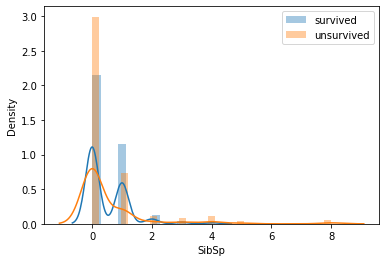

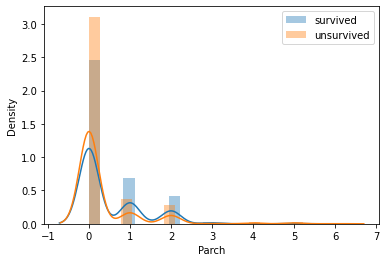

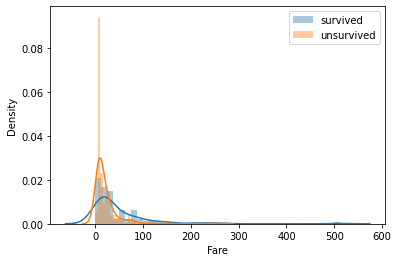

In [17]:
for col in quantitative_col :
    plt.figure()
    sns.distplot(survived_people[col], label='survived')
    sns.distplot(unsurvived_people[col], label='unsurvived')
    plt.legend()

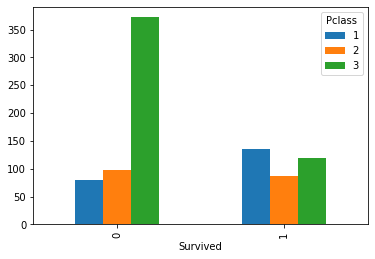

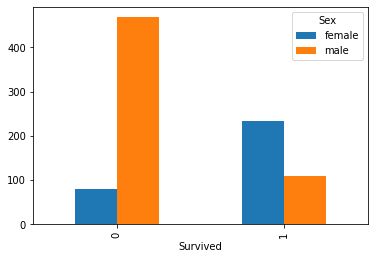

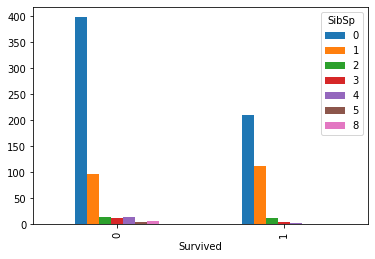

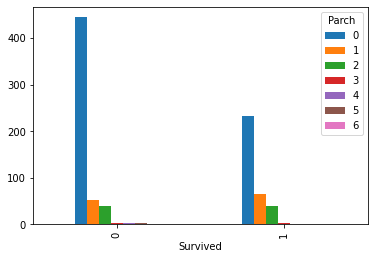

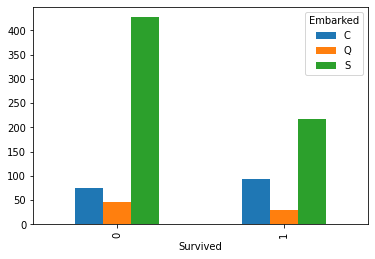

In [18]:
for col in ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked'] :
    pd.crosstab(train['Survived'], train[col]).plot.bar()

let's see what hapens with SibSp and Parch :

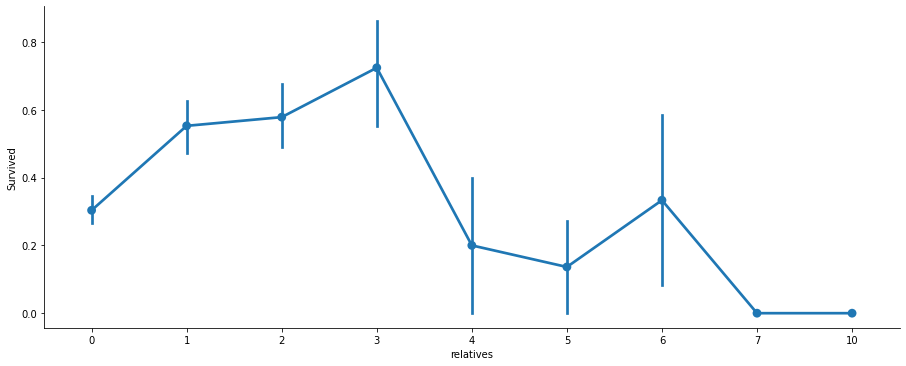

In [19]:
data = [train, test]

for dataset in data:
    dataset['relatives'] = dataset['SibSp'] + dataset['Parch']
    dataset.loc[dataset['relatives'] > 0, 'travelled_alone'] = 'No'
    dataset.loc[dataset['relatives'] == 0, 'travelled_alone'] = 'Yes'

axes = sns.factorplot('relatives','Survived', 
                      data=train, aspect = 2.5, )

- Pclass and Fare are highly correlated with our target and between each other, also SibSp and Parch have significant correlation with it and also between each other
- The younger you are the more likely to survive
- More people in class 3 died
- females have more chance to survive
- Alone People have more chance to dy and if you travel with 1 to 3 people you have more chance to survive
- People who travel from C have more chance to not survive

# 2. Pre-Processing :

In [20]:
# concatenate train and test set for the pre-processing
df = train.append(test).reset_index(drop=True)

## Feature Engineering :

In [21]:
for i in range(len(df)):
    if not(pd.isnull(df['Cabin'].iloc[i])):
        df['Cabin'].iloc[i]=df['Cabin'].iloc[i][0] 
    else :
        df['Cabin'].iloc[i]='No'

In [22]:
# add familly size column
df['Fsize'] = df['Parch'] + df['SibSp'] + 1

In [23]:
df['travelled_alone'] = 'No'
df.loc[df.Fsize == 1, 'travelled_alone'] = 'Yes'

In [24]:
df['Title'] = df['Name'].str.extract('([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Capt', 'Col', 'Rev', 'Don', 'Countess', 'Jonkheer', 'Dona', 'Sir', 'Dr', 'Major', 'Dr'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Mme', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace(['Lady'], 'Mrs')

## Imputation :

In [25]:
df.Embarked.fillna(train.Embarked.mode()[0], inplace = True)

In [26]:
mean = train["Age"].mean()
std = train["Age"].std()

is_null = df["Age"].isnull().sum()
# compute random numbers between the mean, std and is_null
rand_age = np.random.randint(mean - std, mean + std, size = is_null)
# fill NaN values in Age column with random values generated
age_slice = df["Age"].copy()
age_slice[np.isnan(age_slice)] = rand_age

df["Age"] = age_slice
df["Age"] = df["Age"].astype(int)

In [27]:
df['Fare'].fillna(train['Fare'].mean(), inplace = True)

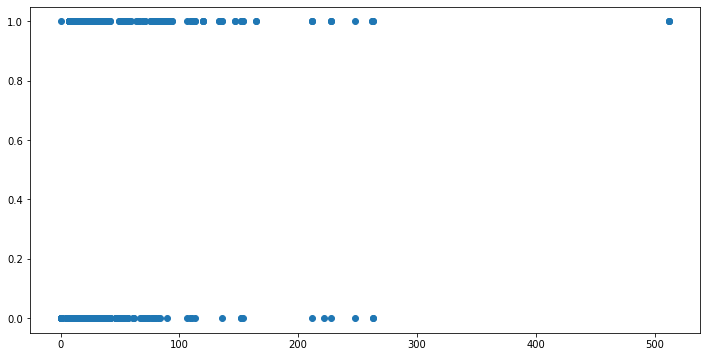

In [28]:
plt.figure(figsize=(12,6))
plt.scatter(train.Fare, train.Survived)

In [29]:
train.Fare.max()

512.3292

In [30]:
test.Fare.max()

512.3292

In [31]:
train[train.Fare>300].Fare.count() # there is just three elements between 300 and 5** so we will remove it

3

In [32]:
test[test.Fare>300].Fare.count()

1

    There are probably other outliers in the training data. However, removing all them may affect badly our models if ever there were also outliers in the test data. 
  
  Outliers removal is note always safe. 
  
  Ps : I tried with removing these three samples (Fare column) and the result become worse!  So I will keep it.

## Encoding :

In [33]:
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked', 'relatives', 'travelled_alone',
       'PassengerId', 'Fsize', 'Title'],
      dtype='object')

In [34]:
features = ["Sex", "Pclass","travelled_alone", "Cabin", "Embarked", "Title"]

In [35]:
df=pd.get_dummies(df,columns=features,drop_first=True)

In [36]:
df.head(2)

,Survived,Name,Age,SibSp,Parch,Ticket,Fare,relatives,PassengerId,Fsize,...,Cabin_F,Cabin_G,Cabin_No,Cabin_T,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,0.0,"Braund, Mr. Owen Harris",22,1,0,A/5 21171,7.2500,1,NaN,2,...,0,0,1,0,0,1,0,1,0,0
1,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38,1,0,PC 17599,71.2833,1,NaN,2,...,0,0,0,0,0,0,0,0,1,0


In [37]:
df.drop(['Name', 'Ticket'], axis = 1, inplace = True)

In [38]:
train = df[:n ] # the three outliers
test = df[n:]

In [39]:
train.isna().sum() / train.shape[0] * 100

Survived                 0.0
Age                      0.0
SibSp                    0.0
Parch                    0.0
Fare                     0.0
relatives                0.0
PassengerId            100.0
Fsize                    0.0
Sex_male                 0.0
Pclass_2                 0.0
Pclass_3                 0.0
travelled_alone_Yes      0.0
Cabin_B                  0.0
Cabin_C                  0.0
Cabin_D                  0.0
Cabin_E                  0.0
Cabin_F                  0.0
Cabin_G                  0.0
Cabin_No                 0.0
Cabin_T                  0.0
Embarked_Q               0.0
Embarked_S               0.0
Title_Miss               0.0
Title_Mr                 0.0
Title_Mrs                0.0
Title_Rare               0.0
dtype: float64

In [40]:
test.isna().sum() / test.shape[0] * 100

Survived               100.0
Age                      0.0
SibSp                    0.0
Parch                    0.0
Fare                     0.0
relatives                0.0
PassengerId              0.0
Fsize                    0.0
Sex_male                 0.0
Pclass_2                 0.0
Pclass_3                 0.0
travelled_alone_Yes      0.0
Cabin_B                  0.0
Cabin_C                  0.0
Cabin_D                  0.0
Cabin_E                  0.0
Cabin_F                  0.0
Cabin_G                  0.0
Cabin_No                 0.0
Cabin_T                  0.0
Embarked_Q               0.0
Embarked_S               0.0
Title_Miss               0.0
Title_Mr                 0.0
Title_Mrs                0.0
Title_Rare               0.0
dtype: float64

## Train test split :

In [41]:
X = train.drop(['Survived','PassengerId'], axis = 1)
y = train.Survived
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 3. Modeling and Evaluation :

In [42]:
def evaluation(model):
    
    model.fit(x_train, y_train)
    ypred = model.predict(x_test)
    
    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))
    
    N, train_score, val_score = learning_curve(model, x_train, y_train,
                                              cv=4, scoring='f1',
                                               train_sizes=np.linspace(0.1, 1, 10))
    
    
    plt.figure(figsize=(12, 8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()
    
    

In [43]:
model = RandomForestClassifier(random_state=0)

[[100  10]
 [ 19  50]]
              precision    recall  f1-score   support

         0.0       0.84      0.91      0.87       110
         1.0       0.83      0.72      0.78        69

    accuracy                           0.84       179
   macro avg       0.84      0.82      0.82       179
weighted avg       0.84      0.84      0.84       179



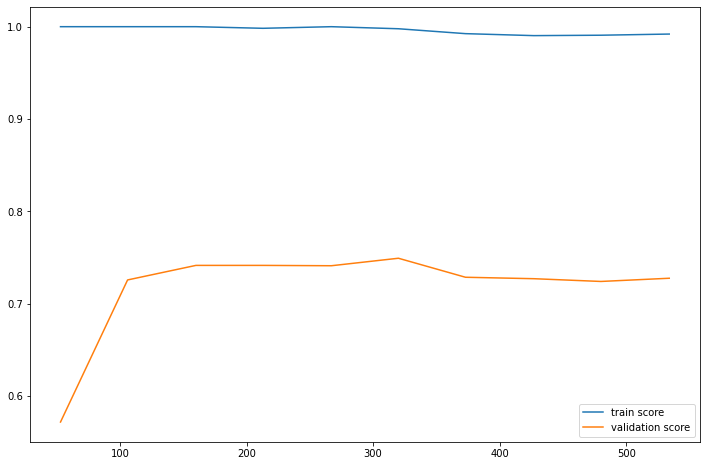

In [44]:
evaluation(model)

In [45]:
preprocessor = make_pipeline(PolynomialFeatures(2, include_bias=False), SelectKBest(f_classif, k=10))

In [46]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KNN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())

In [47]:
dict_of_models = {'RandomForest': RandomForest,
                  'SVM': SVM,
                  'KNN': KNN
                 }

RandomForest
[[83 27]
 [15 54]]
              precision    recall  f1-score   support

         0.0       0.85      0.75      0.80       110
         1.0       0.67      0.78      0.72        69

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       179
weighted avg       0.78      0.77      0.77       179

SVM
[[92 18]
 [18 51]]
              precision    recall  f1-score   support

         0.0       0.84      0.84      0.84       110
         1.0       0.74      0.74      0.74        69

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179

KNN
[[85 25]
 [16 53]]
              precision    recall  f1-score   support

         0.0       0.84      0.77      0.81       110
         1.0       0.68      0.77      0.72        69

    accuracy                           0.77       179
   macro avg       0.76      0.77      0.76       

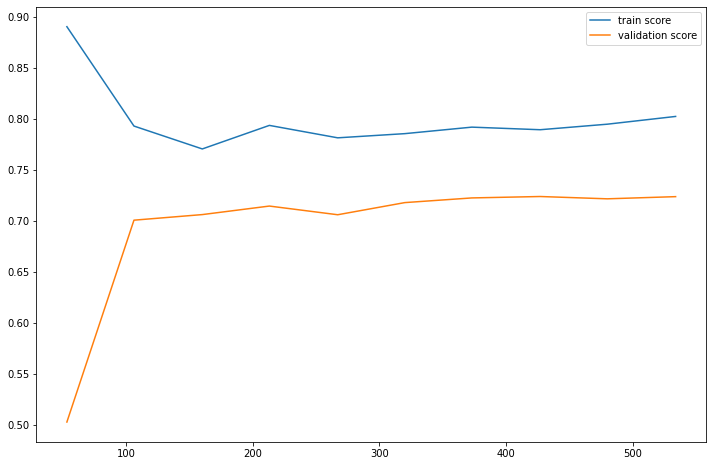

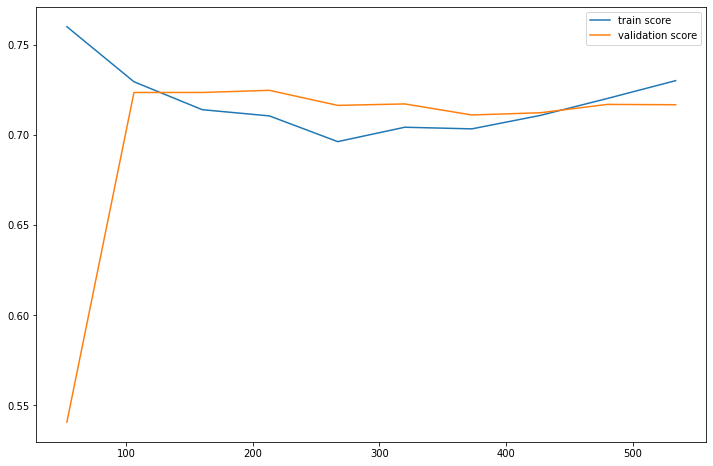

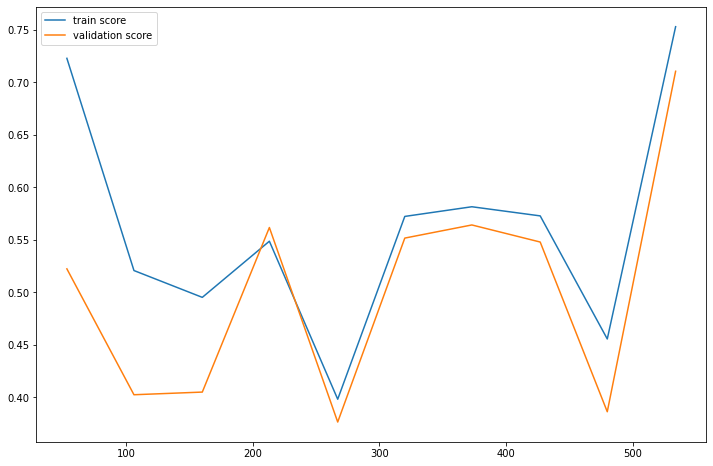

In [48]:
for name, model in dict_of_models.items():
    print(name)
    evaluation(model)

In [49]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [50]:
SVM

Pipeline(steps=[('pipeline',
                 Pipeline(steps=[('polynomialfeatures',
                                  PolynomialFeatures(include_bias=False)),
                                 ('selectkbest', SelectKBest())])),
                ('standardscaler', StandardScaler()),
                ('svc', SVC(random_state=0))])

In [51]:
hyper_params = {'svc__gamma':[1e-3, 1e-4, 0.0005],
                'svc__C':[1, 10, 100, 1000, 3000], 
               'pipeline__polynomialfeatures__degree':[2, 3],
               'pipeline__selectkbest__k': range(45, 60)}

In [52]:
grid = RandomizedSearchCV(SVM, hyper_params, scoring='recall', cv=4,
                          n_iter=40)

grid.fit(x_train, y_train)
print(grid.best_params_)

{'svc__gamma': 0.0005, 'svc__C': 1, 'pipeline__selectkbest__k': 48, 'pipeline__polynomialfeatures__degree': 3}


[[83 27]
 [16 53]]
              precision    recall  f1-score   support

         0.0       0.84      0.75      0.79       110
         1.0       0.66      0.77      0.71        69

    accuracy                           0.76       179
   macro avg       0.75      0.76      0.75       179
weighted avg       0.77      0.76      0.76       179



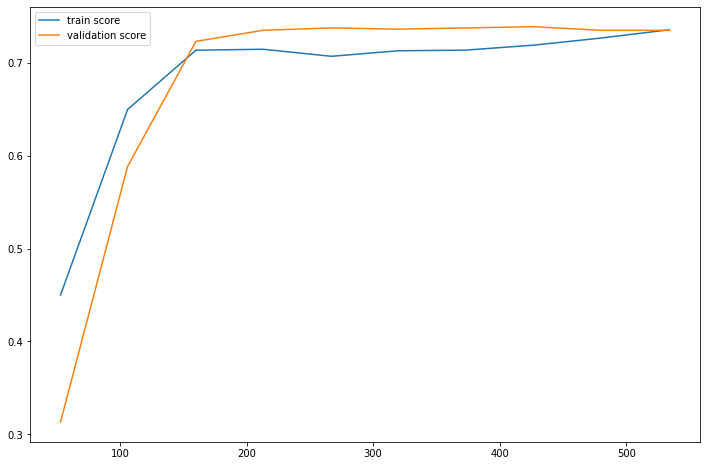

In [53]:
evaluation(grid.best_estimator_)

In [54]:
submit = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

In [55]:
submit['Survived']=grid.predict(test.drop(['Survived', 'PassengerId'], axis = 1)).astype('int')
submit.to_csv('submission.csv',index=False)

In [56]:
submit.head(2)

,PassengerId,Survived
0,892,0
1,893,1


### If you find this notebook useful, please don't forget to upvote it!